In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import reload
import importlib

import beta_compute

from beta_compute import BetaEstimator
importlib.reload(beta_compute)
from beta_compute import BetaEstimator
from tqdm import trange

import inspect
import pickle as pkl

In [ ]:
stn_req = 3.0
stn_band = (2.667, 6.0)

working_dir = "/Users/ivandevert/prog/spectral-falloff-ratio/testing/tmp/"

nkeep = 50000


In [3]:
# load an example df 
full_df = pd.read_pickle("/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/p_spectra.pkl")
n = len(full_df)


In [4]:
filtered_df = full_df.copy()
filtered_df['direction'] = filtered_df['stid'].str[-1:]
# drop rows that don't have filtered_df['direction'] == 'Z'
filtered_df = filtered_df[filtered_df['direction'] == 'Z'].reset_index(drop=True)
# drop direction column
filtered_df = filtered_df.drop('direction', axis=1)


In [ ]:

# # # select nkeep records using rng
# rng = np.random.default_rng(42)
# inds = rng.choice(n, size=nkeep, replace=False)

# df = full_df.iloc[inds]
# df.reset_index(inplace=True, drop=True)

# use full df
df = filtered_df.copy()


nf = len(df['s2'].values[0])

# equally spaced array len=nf from 0 to 50
f = np.linspace(0, 50, nf)

# get indices of stn band
stn_i1 = np.argmin(np.abs(f - stn_band[0]))
stn_i2 = np.argmin(np.abs(f - stn_band[1]))

spectra = df[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

noise = df[['s1']].values
noise = np.stack(noise.flatten()).astype(float)

# filter out low-STN records
df['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# remove records with stn < stn_req
df = df[df['stn'] > stn_req].reset_index(drop=True)

# correct s2 to displacement

spectra = df[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

# this is correct, as long as input spectra are native units (HH* = velocity, HN* = acceleration)
# could be more efficient though
f_corr = np.copy(f)
f_corr[0] = f_corr[1] / 2 #fudge
df['units'] = df['stid'].str[-2]
powers = np.zeros(len(df), dtype=int)
powers[df['units'] == 'N'] = -2
powers[df['units'] == 'H'] = -1
powers = np.tile(powers[:, np.newaxis], (1, nf))
corr = (2*np.pi*f_corr)**powers
df.drop(columns=['units'], inplace=True)

spectra = spectra * corr

df['s2'] = list(spectra)

# drop s1 and s2 columns
# df.drop(columns=['s1', 's2'], inplace=True)
df.drop(columns=['s1'], inplace=True)


In [118]:
# brune = 1 / (1 + (f_corr / 30)**2)
# brune_acc = brune * (2*np.pi*f_corr)**2

# brune_corr = brune_acc * (2*f_corr*np.pi)**-2

# plt.figure()
# plt.plot(f_corr, corr[:10, :].T, c='b', lw=2)
# plt.plot(f_corr, brune, c='k', lw=2, label='disp brune')
# plt.plot(f_corr, brune_acc, c='r', lw=2, label='acc brune')
# plt.plot(f_corr, brune_corr, 'r--', lw=2, label='corrected brune')
# # plt.plot(f_corr, (2*f_corr*np.pi)**-1, c='lime', ls=':', label='velocity correction')
# plt.plot(f_corr, (2*f_corr*np.pi)**-2, c='lime', ls=':', label='acc correction')




# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Correction')
# plt.legend()
# plt.xscale('log')
# plt.yscale('log')
# plt.show()

In [119]:
powers[:30,0]

array([-1, -1, -1, -1, -2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -2, -1, -1,
       -2, -1, -2, -1, -1, -2, -1, -2, -1, -1, -1, -1, -1])

In [103]:
print(f"Number of original records: {len(filtered_df):,}")
print(f"Number of final records: {len(df):,}")

print(f"\nNumber of original events: {len(filtered_df['event_id'].unique()):,}")
print(f"Number of final events: {len(df['event_id'].unique()):,}")

Number of original records: 943,517
Number of final records: 313,783

Number of original events: 12,935
Number of final events: 12,684


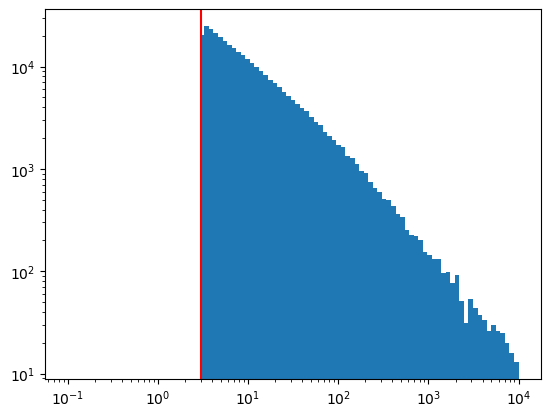

In [104]:
# plot histogram of stn
plt.figure()
plt.hist(df['stn'].values, bins=np.logspace(-1, 4, 100))
plt.axvline(stn_req, c='r')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [9]:
# # toy problem:
# # assume all calib_sid are in target_sid and all target_sid are in calib_sid
# target_sid = np.array([0, 1, 4, 7, 9]) # these should be unique (1 event, many stations)
# calib_sid = np.array([4, 4, 7, 0, 1, 4, 9, 9]) # these are not necessarily unique (many events, many stations)

# target_logbeta = np.array([0.5, 0.1, -1.0, -2.4, 0.8])
# calib_logbeta = np.array([5, 6, 7, 8, 9, 10, 11, 12])

# # indices of target_sid in calib_sid
# v = np.searchsorted(target_sid, calib_sid)
# print('v:', v)
# print('calib_logbeta:', calib_logbeta[v])

# print('target_sid[v]:', target_sid[v])
# print('target_logbeta[v]:', target_logbeta[v])

# print('want -1, -1, -2.4, 0.5, 0.1, -1, 0.8, 0.8')


In [10]:
# # synthetic test: logbeta vs distance should be linear, right?
# f = np.linspace(0, 50, 76)
# kappa0 = 0.006
# kappaR = 0.00006
# ns = 100


# def compute_logbeta(spectra, low_f_ind, high_f_ind):
#     # spectra is an (N x nf) array
#     low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
#     high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
#     logbeta = high_band - low_band
#     return logbeta


# # R is uniform random between 0 and 100, length ns. set seed also.
# np.random.seed(42)
# R = np.random.uniform(0, 100, ns)

# # generate a brune model for a ~M1.5 event (fc=30)
# s2 = 1 / (1 + (f / 30)**2)
# s2 = np.tile(s2, (ns, 1))

# s0 = s2[0,:]

# # generate attenuation curves
# atten = np.exp(-np.pi * kappa0 * f) * np.exp(-np.pi * kappaR * R[:, np.newaxis] * f)

# noise = np.abs(np.random.normal(0, 0.3, (ns, len(f)))+1)

# observed = s2 * atten * noise

# logbeta = compute_logbeta(observed, low_f_ind=(2,8), high_f_ind=(23, 33))

# col = R / np.max(R)
# cmap = plt.get_cmap('RdBu')
# plt.figure()
# for i in range(ns):
#     plt.plot(f, observed[i,:], c=cmap(col[i]))
# plt.plot(f, s0, c='k')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Frequency (Hz)')
# plt.show()

# plt.figure()
# plt.scatter(R, logbeta, s=1, c='k', edgecolors='none')
# plt.xlabel('Distance (km)')
# plt.ylabel('logbeta')
# plt.show()


Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,684
Stations: 169
Records:  313,783

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.40 to 1.60
Calibration events:  1,724 (13.59%)
Calibration records: 33,744 (10.75%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.


100%|██████████| 101/101 [00:01<00:00, 68.87it/s]


Best-fit slope: -0.007676
logbeta_brune =  [-0.13679788]


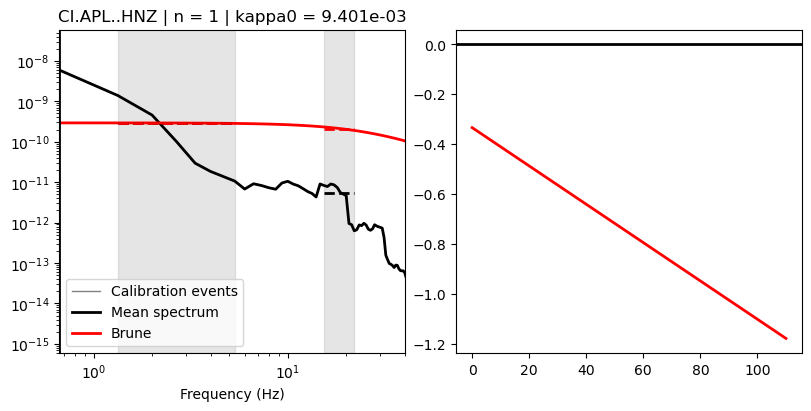

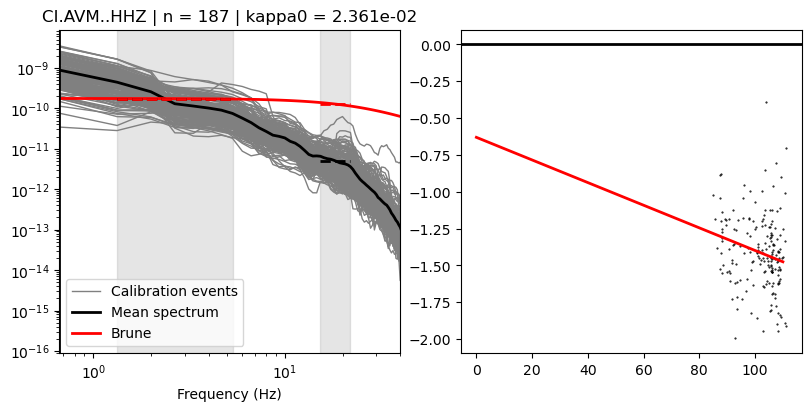

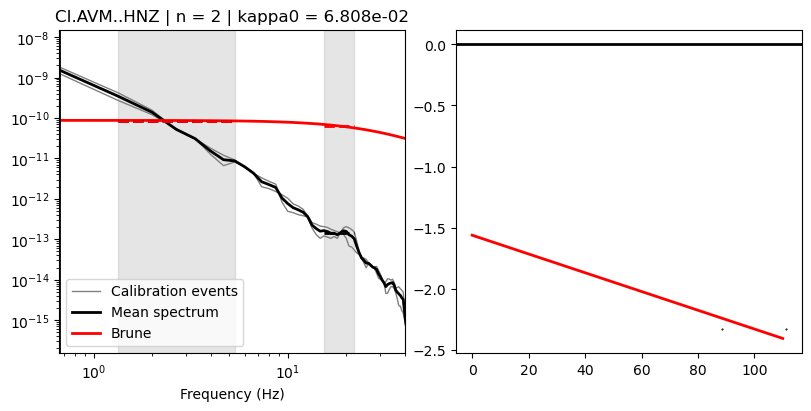

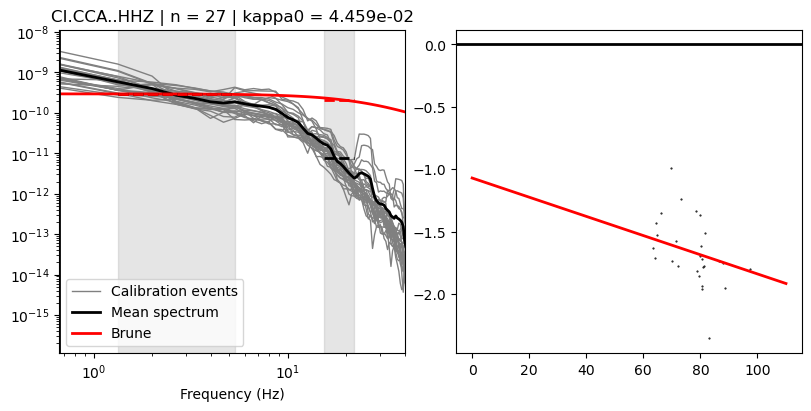

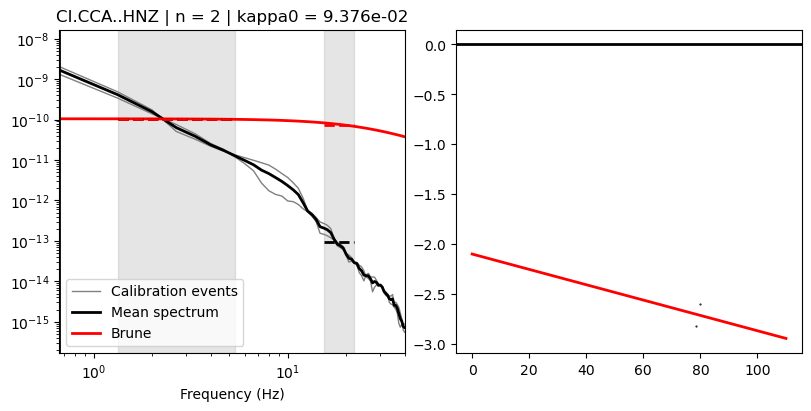

In [130]:

importlib.reload(beta_compute)
from beta_compute import BetaEstimator

results = BetaEstimator(metadata_df=df, spectra=spectra, f=f)
results = results.compute(recompute=False)
# results = results.compute(recompute=True)
results = results.estimate_kappa0(fc_fixed=30, )

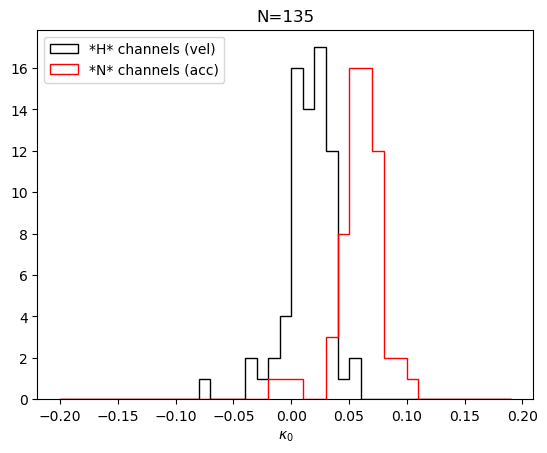

In [128]:
res = results.df_sta[['station_name', 'kappa0', 'slat', 'slon']].copy()
res['units'] = res['station_name'].str[-2]

# drop rows with kappa0=NaN
res = res.dropna(subset=['kappa0']).reset_index(drop=True)

edges = np.arange(-0.2, 0.2, 0.01)
midpoints = (edges[:-1] + edges[1:])/2

plt.figure()
plt.hist(res['kappa0'][res['units'] == 'H'], color='k', bins=edges, histtype='step', label='*H* channels (vel)')
plt.hist(res['kappa0'][res['units'] == 'N'], color='r', bins=edges, histtype='step', label='*N* channels (acc)')
plt.xlabel(r"$\kappa_0$")
plt.title(f"N={len(res)}")
plt.legend()
plt.show()

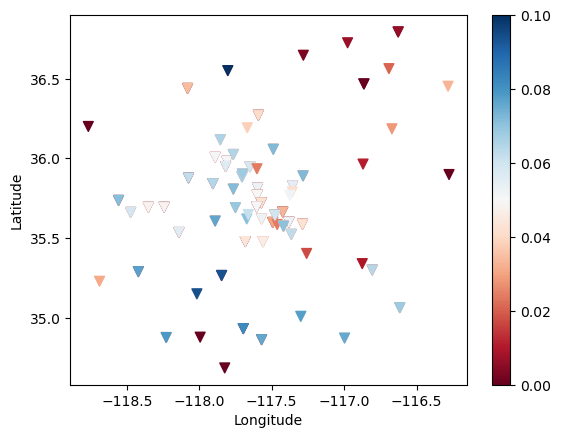

In [129]:
plt.figure()
plt.scatter(res['slon'], res['slat'], c=res['kappa0'], cmap='RdBu', marker='v', s=50, vmin=0, vmax=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar()
plt.show()

In [84]:
results.metadata_calib['deldist'].min()

0.08782866597175598

In [68]:
# hist of results.kappa0

plt.figure()
plt.hist(results.kappa0, bins=25)
plt.xlabel(r"$\kappa_0$")
plt.ylabel('Count')
plt.show()

AttributeError: 'BetaEstimator' object has no attribute 'kappa0'

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12,4), sharex=True, layout='constrained')
axs[0].scatter(results.metadata_df['emag'], results.metadata_df['logbeta'], s=0.1, c='k', edgecolors='none')
axs[1].scatter(results.metadata_df['emag'], results.metadata_df['dlogbeta'], s=0.5, c='k', edgecolors='none')
axs[1].plot(results.correction_mags, results.correction_function, c='r', marker='o')
axs[2].scatter(results.metadata_df['emag'], results.metadata_df['dlogbeta_corr'], s=0.5, c='k', edgecolors='none')

ylim = [np.min(results.metadata_df['logbeta'])-.25, np.max(results.metadata_df['logbeta'])+.25]
axs[0].set_ylim(ylim)
axs[1].set_ylim(ylim)
axs[2].set_ylim(ylim)

xlim = [results.metadata_df['emag'].min()-results.mag_corr_dM/1.99, results.metadata_df['emag'].max()]
axs[0].set_xlim(xlim)
axs[1].set_xlim(xlim)
axs[2].set_xlim(xlim)

axs[1].set_xlabel("Magnitude")
axs[0].set_ylabel(r"$\log\beta$")
axs[1].set_ylabel(r"$\Delta\log\beta$")
axs[2].set_ylabel(r"$\Delta\log\beta^*$")
plt.show()



In [ ]:
full_df_s = pd.read_pickle("/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/s_spectra.pkl")

spectra_s = full_df_s[['s2']].values
spectra_s = np.stack(spectra_s.flatten()).astype(float)


results_s = BetaEstimator(metadata_df=full_df_s, spectra=spectra_s, f=f)
results_s.compute()


In [ ]:
plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['logbeta'], s=1, c='k', edgecolors='none')
plt.ylim([-3,3])
plt.show()

plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['dlogbeta'], s=1, c='k', edgecolors='none')
plt.plot(results_s.correction_mags, results_s.correction_function, c='r', marker='o')
plt.ylim([-3,3])
plt.show()

plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['dlogbeta_corr'], s=1, c='k', edgecolors='none')
plt.ylim([-3,3])
plt.show()

In [ ]:
print(np.max(results.metadata_df['ex']) - np.min(results.metadata_df['ex']))
print(np.max(results.metadata_df['ey']) - np.min(results.metadata_df['ey']))

In [ ]:
np.sum(np.isnan(results.metadata_df['dlogbeta']))

In [ ]:
# importlib.reload(beta_compute)
# from beta_compute import BetaEstimator

test_df = metadata_df.copy()

test_df = beta_compute._get_id_from_column(test_df, 'event_id', 'eid')
test_df = beta_compute._get_id_from_column(test_df, 'stid', 'sid')
# test_df[test_df['sid']==7]